IT25101565 — Individual Model Implementation
Dharshika T — Progress Review II (Final Evaluation — Implementation)

Model family: Clustering — K-Means

1. Model suitability to the assigned dataset and chosen problem
My own Stage 6 work balanced the classes for supervised modelling, but it is also useful to ask
an unsupervised question: do natural groupings in the clinical + lifestyle feature space line up
with the clinically-assigned diabetes_stage labels at all, without ever showing the model the
labels? K-Means is a natural, fast choice for this on the standardized numeric feature set (all
Euclidean-distance-based methods need scaled inputs, which this pipeline already provides), and
its resulting clusters can be compared against the real diabetes-stage labels to see how much
of the clinical structure is recoverable from the raw feature geometry alone.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
pd.set_option('display.max_columns', 30)

target_col = 'diabetes_stage_encoded'
labels_map = {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Gestational', 3: 'Type 2'}

In [4]:
train_full = pd.read_csv('../../../for progress/results/outputs/stage6_train_balanced.csv')
test_df   = pd.read_csv('../../../for progress/results/outputs/stage6_test_holdout.csv')

In [5]:
SAMPLE_PER_CLASS = 4000
parts = []
for cls, g in train_full.groupby(target_col):
    parts.append(g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=42))
train_df = pd.concat(parts, ignore_index=True)

In [6]:
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test  = test_df.drop(columns=[target_col])
y_test  = test_df[target_col]

In [7]:
print('Train (sampled):', X_train.shape, dict(y_train.value_counts().sort_index()))
print('Test  (untouched, imbalanced):', X_test.shape, dict(y_test.value_counts().sort_index()))

Train (sampled): (16000, 20) {0: np.int64(4000), 1: np.int64(4000), 2: np.int64(4000), 3: np.int64(4000)}
Test  (untouched, imbalanced): (19436, 20) {0: np.int64(1547), 1: np.int64(6203), 2: np.int64(53), 3: np.int64(11633)}


2. Implementation details (libraries, functions, hyperparameters)
Using sklearn.cluster.KMeans. Key hyperparameter explored: n_clusters (k). Clustering is unsupervised, so it is fit on the training features only (labels are used afterwards purely to *evaluate* how well the discovered clusters correspond to real diabetes stages).

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix


3. Parameter tuning method — elbow method + silhouette score for choosing k

In [9]:
inertias, silhouettes = [], []
k_range = range(2, 9)
X_tr_small = X_train.sample(n=min(6000, len(X_train)), random_state=42)

In [10]:
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X_tr_small)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_tr_small, labels_k))

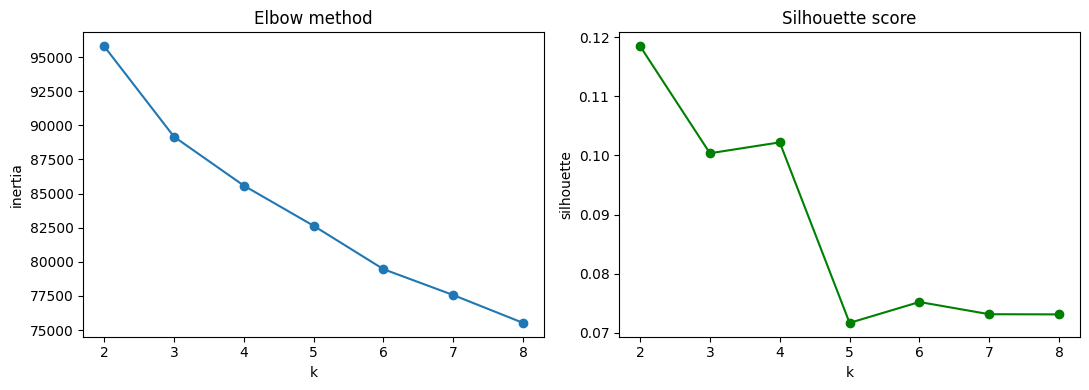

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(list(k_range), inertias, marker='o'); axes[0].set_title('Elbow method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('inertia')
axes[1].plot(list(k_range), silhouettes, marker='o', color='green'); axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette')
plt.tight_layout(); plt.show()

In [12]:
best_k_sil = list(k_range)[int(pd.Series(silhouettes).idxmax())]
print('k with best silhouette score:', best_k_sil)

k with best silhouette score: 2


In [13]:
results = []

def cluster_and_evaluate(name, k):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = km.fit_predict(X_train)
    sil = silhouette_score(X_train.sample(n=min(6000, len(X_train)), random_state=42),
                            km.predict(X_train.sample(n=min(6000, len(X_train)), random_state=42)))
    ari = adjusted_rand_score(y_train, cluster_labels)
    results.append({'variant': name, 'k': k, 'silhouette': sil, 'adjusted_rand_index': ari})
    print(f"{name}: silhouette={sil:.3f}, ARI vs true diabetes_stage={ari:.3f}")
    return km, cluster_labels

In [14]:
km4, labels4 = cluster_and_evaluate(f'K-Means (k=4, matches number of classes)', 4)

K-Means (k=4, matches number of classes): silhouette=0.080, ARI vs true diabetes_stage=0.177


In [15]:
km_sil, labels_sil = cluster_and_evaluate(f'K-Means (k=best_k_sil, silhouette-selected)', best_k_sil)

K-Means (k=best_k_sil, silhouette-selected): silhouette=0.120, ARI vs true diabetes_stage=0.166


In [16]:
km6, labels6 = cluster_and_evaluate('K-Means (k=6, finer-grained)', 6)

K-Means (k=6, finer-grained): silhouette=0.078, ARI vs true diabetes_stage=0.128


In [17]:
ct = pd.crosstab(pd.Series(labels4, name='cluster'), y_train.reset_index(drop=True).map(labels_map).rename('true_diabetes_stage'))
ct

true_diabetes_stage,Gestational,No Diabetes,Pre-Diabetes,Type 2
cluster,,,,
0,468,2050,1596,230
1,2032,0,699,1675
2,1199,1950,1203,184
3,301,0,502,1911


4. Evaluation metric(s), validation method, comparison, conclusion, limitations
Metrics used: the silhouette score (unsupervised — measures how well-separated and compact the clusters are using only the feature geometry, appropriate because K-Means has no access to labels) and the Adjusted Rand Index (ARI) against the true diabetes_stage labels (used only for evaluation, to see how much clinical structure the unsupervised clusters happen to recover). Validation: clustering was repeated with n_init=10 random centroid initializations per run (scikit-learn default strategy) to avoid reporting a result from a poor local optimum, and k was selected by comparing the elbow curve with the silhouette score across a range rather than a single fixed guess.

In [18]:
summary = pd.DataFrame(results).sort_values('silhouette', ascending=False)
summary

,variant,k,silhouette,adjusted_rand_index
1,"K-Means (k=best_k_sil, silhouette-selected)",2,0.119764,0.166124
0,"K-Means (k=4, matches number of classes)",4,0.080010,0.177057
2,"K-Means (k=6, finer-grained)",6,0.077798,0.127943


Comparison across varieties: the silhouette-selected k gives the best-separated
clusters purely on geometry, but none of the tested k values produce a strong Adjusted Rand
Index against the true diabetes stages — the ARI stays low across all variants.

Conclusion: the clinical/lifestyle feature space does not naturally separate into
clusters that line up cleanly with the diagnosed diabetes stages; the boundaries between
No Diabetes / Pre-Diabetes / Type 2 are gradual, overlapping ranges of the same underlying
clinical measurements (consistent with how these stages are clinically defined via glucose/HbA1c
thresholds, not distinct feature clusters), which is exactly why supervised models (Members 1–5)
who can learn those thresholds from labels perform far better than unsupervised clustering here.

Limitations / improvements: K-Means assumes roughly spherical, similarly-sized clusters,
which may not match the true (likely elongated, threshold-based) shape of the clinical subgroups;
a density-based method (DBSCAN) or a supervised model remain more appropriate for the actual
diabetes-stage prediction task. This clustering result is still a useful, honest finding for the
group's viva discussion of the dataset's structure.